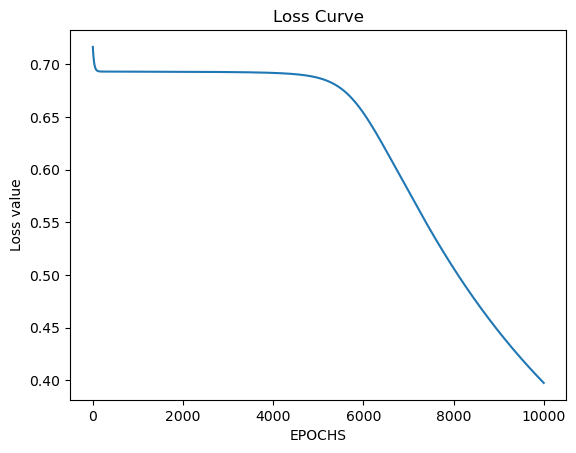

Input  Output
[[1, 0]]      1
[[1, 1]]      0
[[0, 1]]      1
[[0, 0]]      0


In [1]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

# Input and Output for XOR
x = np.array([[0,0,1,1],
              [0,1,0,1]])

y = np.array([[0,1,1,0]])

# Number of neurons
n_x = 2
n_h = 2
n_y = 1

m = x.shape[1]
lr = 0.1

# Initialize weights
np.random.seed(2)

w1 = np.random.rand(n_h, n_x)
w2 = np.random.rand(n_y, n_h)

losses = []

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward propagation
def forward_prop(w1, w2, x):
    z1 = np.dot(w1, x)
    a1 = sigmoid(z1)

    z2 = np.dot(w2, a1)
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

# Backward propagation
def back_prop(m, w1, w2, z1, a1, z2, a2, y):
    
    dz2 = a2 - y
    dw2 = np.dot(dz2, a1.T) / m

    dz1 = np.dot(w2.T, dz2) * a1 * (1 - a1)
    dw1 = np.dot(dz1, x.T) / m

    dw1 = np.reshape(dw1, w1.shape)
    dw2 = np.reshape(dw2, w2.shape)

    return dw2, dw1
# Training
iterations = 10000

for i in range(iterations):

    z1, a1, z2, a2 = forward_prop(w1, w2, x)

    loss = -(1/m) * np.sum(y*np.log(a2) + (1-y)*np.log(1-a2))

    losses.append(loss)

    dw2, dw1 = back_prop(m, w1, w2, z1, a1, z2, a2, y)

    w2 = w2 - lr * dw2
    w1 = w1 - lr * dw1

# Plot Loss Graph
plt.plot(losses)
plt.xlabel("EPOCHS")
plt.ylabel("Loss value")
plt.title("Loss Curve")
plt.show()

# Prediction Function
def predict(w1, w2, test):

    z1, a1, z2, a2 = forward_prop(w1, w2, test)

    output = 1 if a2 >= 0.5 else 0

    print(f"{test.T.tolist()}      {output}")

# Testing
print("Input  Output")

tests = [
    np.array([[1],[0]]),
    np.array([[1],[1]]),
    np.array([[0],[1]]),
    np.array([[0],[0]])
]

for test in tests:
    predict(w1, w2, test)